# Part C — Email Spam Representation Improvement

## Representation change: Feature Selection

The supplied `emails.csv` dataset contains 5,172 emails represented by 3,000 numerical features.

For Part C, this notebook compares:
- **Original representation:** all 3,000 features
- **Improved representation:** the 500 most informative features selected using `SelectKBest` with the chi-squared test

We compare accuracy, precision, recall, F1, training time, prediction time, and dimensionality.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [5]:
# Load dataset
path = "C:\\Users\\rutup\\.cache\\kagglehub\\datasets\\balaka18\\email-spam-classification-dataset-csv\\versions\\1"
DATASET_FILE = path + "\\emails.csv"
email_df = pd.read_csv(DATASET_FILE)

print("Dataset shape:", email_df.shape)
display(email_df.head())

Dataset shape: (5172, 3002)


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [6]:
# Separate features and target
X = email_df.drop(columns=["Email No.", "Prediction"])
y = email_df["Prediction"]

print("Samples:", X.shape[0])
print("Original features:", X.shape[1])
print("Classes:", sorted(y.unique()))

Samples: 5172
Original features: 3000
Classes: [np.int64(0), np.int64(1)]


## Train-test split

We split the data before feature selection. This prevents information from the test set from influencing which features are selected.

`stratify=y` preserves the spam/non-spam class proportions.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4137
Testing samples: 1035


# Experiment 1 — Original 3,000-feature representation

In [8]:
baseline_model = LogisticRegression(max_iter=1000)

start = time.perf_counter()
baseline_model.fit(X_train, y_train)
baseline_train_time = time.perf_counter() - start

start = time.perf_counter()
baseline_pred = baseline_model.predict(X_test)
baseline_pred_time = time.perf_counter() - start

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred, zero_division=0),
    "Recall": recall_score(y_test, baseline_pred, zero_division=0),
    "F1 Score": f1_score(y_test, baseline_pred, zero_division=0),
}

print(pd.Series(baseline_metrics).round(4))
print(f"Training time: {baseline_train_time:.6f} s")
print(f"Prediction time: {baseline_pred_time:.6f} s")

Accuracy     0.9826
Precision    0.9578
Recall       0.9833
F1 Score     0.9704
dtype: float64
Training time: 6.599275 s
Prediction time: 0.078469 s


[[722  13]
 [  5 295]]


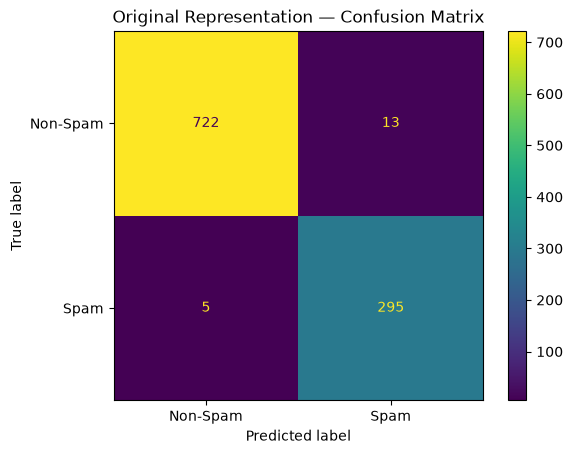

In [9]:
cm = confusion_matrix(y_test, baseline_pred)
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Spam", "Spam"]
).plot()
plt.title("Original Representation — Confusion Matrix")
plt.show()

# Experiment 2 — Reduced 500-feature representation

`SelectKBest(chi2)` ranks features according to their chi-squared association with the target and keeps the top 500.

The selector is fitted **only on training data** and then applied to the test data.

In [10]:
K = 500

selector = SelectKBest(score_func=chi2, k=K)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

print("Original features:", X_train.shape[1])
print("Selected features:", X_train_selected.shape[1])

Original features: 3000
Selected features: 500


In [11]:
reduced_model = LogisticRegression(max_iter=1000)

start = time.perf_counter()
reduced_model.fit(X_train_selected, y_train)
reduced_train_time = time.perf_counter() - start

start = time.perf_counter()
reduced_pred = reduced_model.predict(X_test_selected)
reduced_pred_time = time.perf_counter() - start

reduced_metrics = {
    "Accuracy": accuracy_score(y_test, reduced_pred),
    "Precision": precision_score(y_test, reduced_pred, zero_division=0),
    "Recall": recall_score(y_test, reduced_pred, zero_division=0),
    "F1 Score": f1_score(y_test, reduced_pred, zero_division=0),
}

print(pd.Series(reduced_metrics).round(4))
print(f"Training time: {reduced_train_time:.6f} s")
print(f"Prediction time: {reduced_pred_time:.6f} s")

Accuracy     0.9652
Precision    0.9342
Recall       0.9467
F1 Score     0.9404
dtype: float64
Training time: 3.070407 s
Prediction time: 0.003198 s


[[715  20]
 [ 16 284]]


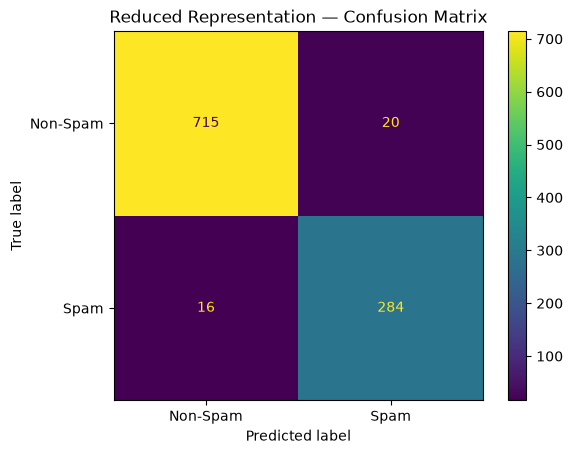

In [12]:
cm = confusion_matrix(y_test, reduced_pred)
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Spam", "Spam"]
).plot()
plt.title("Reduced Representation — Confusion Matrix")
plt.show()

# Original vs Improved Comparison

The comparison table shows the trade-off between dimensionality, computation, and predictive performance.

In [13]:
comparison = pd.DataFrame([
    {
        "Representation": "Original",
        "Features": X_train.shape[1],
        **baseline_metrics,
        "Training Time (s)": baseline_train_time,
        "Prediction Time (s)": baseline_pred_time
    },
    {
        "Representation": "Reduced",
        "Features": X_train_selected.shape[1],
        **reduced_metrics,
        "Training Time (s)": reduced_train_time,
        "Prediction Time (s)": reduced_pred_time
    }
])

display(comparison.round(6))

,Representation,Features,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,Original,3000,0.982609,0.957792,0.983333,0.970395,6.599275,0.078469
1,Reduced,500,0.965217,0.934211,0.946667,0.940397,3.070407,0.003198


In [14]:
original_features = X_train.shape[1]
reduced_features = X_train_selected.shape[1]

reduction = 100 * (original_features - reduced_features) / original_features

print(f"Feature count: {original_features} -> {reduced_features}")
print(f"Dimensionality reduction: {reduction:.2f}%")

Feature count: 3000 -> 500
Dimensionality reduction: 83.33%


## Interpretation

Feature selection reduces the representation from 3,000 to 500 features, removing 83.33% of the dimensions.

The final judgment should be based on the measured results:
- If performance stays similar while computation decreases, the reduced representation is useful.
- If performance drops substantially, useful information may have been removed.
- Training/prediction times should be compared from the table rather than assumed.

This directly addresses the Part C requirement to compare dimensionality, computation, and predictive performance after a representation change.

## Reproducibility

- Dataset: `emails.csv`
- Original features: 3,000
- Selected features: 500
- Feature selection: `SelectKBest(chi2)`
- Classifier: Logistic Regression
- Train/test split: 80% / 20%
- Random state: 42
- Stratified split: Yes
- Logistic Regression `max_iter`: 1000

## 13. Model 3 — Decision Tree

A Decision Tree classifies samples using a sequence of feature-based rules. Unlike Logistic Regression, it can model nonlinear relationships between the image features and the class label.


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
import time
import pandas as pd , numpy as np
import matplotlib.pyplot as plt 

In [11]:
df = pd.read_csv('cracks_data.csv')
dt_model = DecisionTreeClassifier(random_state=42)


feature_columns = [
    "mean_brightness",
    "contrast",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_density",
]

X = df[feature_columns]
y = df["label"]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Training time
start_time = time.time()
dt_model.fit(X_train, y_train)
dt_training_time = time.time() - start_time

# Prediction time
start_time = time.time()
dt_pred = dt_model.predict(X_test)
dt_prediction_time = time.time() - start_time

# Evaluation metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print(f"Accuracy        : {dt_accuracy:.4f}")
print(f"Precision       : {dt_precision:.4f}")
print(f"Recall          : {dt_recall:.4f}")
print(f"F1-score        : {dt_f1:.4f}")
print(f"Training time   : {dt_training_time:.4f} seconds")
print(f"Prediction time : {dt_prediction_time:.4f} seconds")


Features shape: (400, 5)
Labels shape: (400,)
Training samples: 320
Testing samples: 80
Accuracy        : 0.8500
Precision       : 0.8889
Recall          : 0.8000
F1-score        : 0.8421
Training time   : 0.0062 seconds
Prediction time : 0.0018 seconds


### Decision Tree Confusion Matrix


[[36  4]
 [ 8 32]]


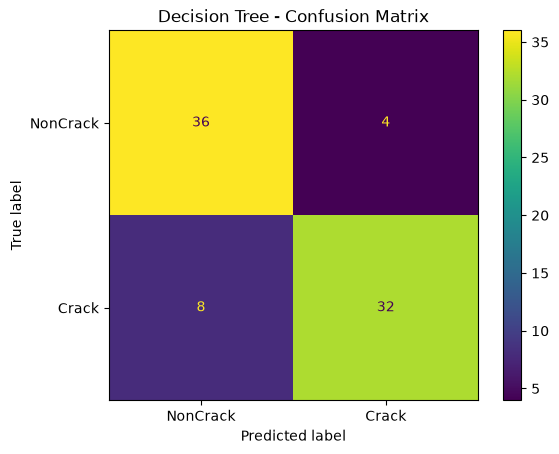

In [12]:
dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["NonCrack", "Crack"]
)
disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()


In [17]:
import pandas as pd

cracks_results_comparison = pd.read_csv('cracks_results_comparison.csv')

# Wrap the scalar values in lists [...]
new_row = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [dt_accuracy],
    "Precision": [dt_precision],
    "Recall": [dt_recall],
    "F1-Score": [dt_f1],
    "Training Time (s)": [dt_training_time],
    "Prediction Time (s)": [dt_prediction_time],
})

cracks_results_comparison = pd.concat([cracks_results_comparison, new_row], ignore_index=True)


In [19]:
cracks_results_comparison.columns

Index(['Unnamed: 0', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score',
       'Training Time (s)', 'Prediction Time (s)'],
      dtype='str')

In [21]:
cracks_results_comparison[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score',
       'Training Time (s)', 'Prediction Time (s)']]

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.6625,0.675676,0.625,0.649351,0.058381,0.002162
1,Random Forest,0.9125,0.923077,0.900,0.911392,0.283064,0.019043
2,Decision Tree,0.8500,0.888889,0.800,0.842105,0.006234,0.001844


## Observations

The observations below should be interpreted from the results produced by the notebook rather than from the model names alone.

1. **Logistic Regression** provides a linear baseline. If its metrics are lower than those of the tree-based models, this indicates that the current five-feature representation may contain nonlinear relationships that a linear decision boundary does not capture as effectively.

2. **Random Forest** combines multiple decision trees and can model more complex feature relationships. Its performance and computational cost should be examined directly in the comparison table.

3. **Decision Tree** also captures nonlinear relationships, but it uses a single tree rather than an ensemble of trees. Its metrics and timing can therefore be compared directly with both Logistic Regression and Random Forest.

4. The extracted representation is intentionally compact: each image is represented using only five global numerical features. This reduces the dimensionality considerably, but it also means that detailed spatial information about where a crack occurs in the image is not explicitly represented.

5. The model comparison is therefore a comparison of both **classifier behavior and the chosen feature representation**. A later representation change can be used to investigate whether different image features improve classification performance or computational efficiency.
